In [1]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
from scipy.stats import binned_statistic, binned_statistic_2d
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from src.loading import *
from src.utils import *

In [2]:
# Load std dev of w over grid
#
std_w = load_coarse_std_gsam_w().sel(z=slice(1e3, 5e3)).mean('z')
# Load and normalize PCs
#
pcs = load_gsam_eofs_pcs().scores()
pcs = pcs/pcs.std(('lat', 'lon', 'time'))
aconv, astrat = pcs.sel(mode=1), pcs.sel(mode=2)
# # Compute the change in pcs over forward difference
# #
# delta_aconv = (
#     aconv.isel(time=slice(1, None)).data - 
#     aconv.isel(time=slice(None, -1)).data
# )
# delta_astrat = (
#     astrat.isel(time=slice(1, None)).data - 
#     astrat.isel(time=slice(None, -1)).data
# )
# # Add a leading NaN layer so shape == aconv.shape
# #
# delta_aconv = np.pad(delta_aconv, ((1,0),(0,0),(0,0)), mode='constant', constant_values=np.nan)
# delta_astrat = np.pad(delta_astrat, ((1,0),(0,0),(0,0)), mode='constant', constant_values=np.nan)
delta_aconv = (aconv.shift(time=-1) - aconv.shift(time=1)) / 1.0
delta_astrat = (astrat.shift(time=-1) - astrat.shift(time=1)) / 1.0


# Digitize pcs by aconv and astrat
#
pc_bins = np.arange(-10, 10, 0.25)
aconv_bin_id  = np.digitize(aconv, bins=pc_bins)
astrat_bin_id = np.digitize(astrat, bins=pc_bins)
aconv_bins_unique  = np.unique(aconv_bin_id)
astrat_bins_unique = np.unique(astrat_bin_id)
# Initialize data of delta_aconv and delta_astrat
#
xmesh, ymesh = np.meshgrid(array_midpoints(pc_bins), array_midpoints(pc_bins))
quiver_data = {
    'delta_aconv_top': np.full_like(xmesh, fill_value=np.nan),
    'delta_aconv_bottom': np.full_like(xmesh, fill_value=np.nan),
    'delta_astrat_top': np.full_like(xmesh, fill_value=np.nan),
    'delta_astrat_bottom': np.full_like(xmesh, fill_value=np.nan),
    'num_obs': np.full_like(xmesh, fill_value=np.nan),
    'delta_aconv': np.full_like(xmesh, fill_value=np.nan),
    'delta_astrat': np.full_like(xmesh, fill_value=np.nan),
}
x=0
for xb in aconv_bins_unique:
    for yb in astrat_bins_unique:
        iy = yb - 1   # row index (y/astrat)
        ix = xb - 1   # col index (x/aconv)
        if iy<0 or ix<0:
            continue
        if ix==pc_bins.size-1 or iy==pc_bins.size-1:
            continue
        # mask points in this bin
        mask = (aconv_bin_id == xb) & (astrat_bin_id == yb)
        quiver_data['num_obs'][iy, ix] = mask.sum()
        # Skip if no points
        if mask.sum() < 50:
            continue
        else:
            x+=1
            bin_std_w = std_w.where(mask)
            top_std_w_mask      = (bin_std_w >= np.nanquantile(bin_std_w, 0.75))
            bottom_std_w_mask   = (bin_std_w <= np.nanquantile(bin_std_w, 0.25))

            quiver_data['delta_aconv_top'][iy, ix]    = np.nanmean(delta_aconv[np.where(top_std_w_mask)])
            quiver_data['delta_aconv_bottom'][iy, ix] = np.nanmean(delta_aconv[np.where(bottom_std_w_mask)])
            quiver_data['delta_astrat_top'][iy, ix]   = np.nanmean(delta_astrat[np.where(top_std_w_mask)])
            quiver_data['delta_astrat_bottom'][iy, ix]= np.nanmean(delta_astrat[np.where(bottom_std_w_mask)])
            quiver_data['delta_aconv'][iy, ix]= np.nanmean(delta_aconv[np.where(mask)])
            quiver_data['delta_astrat'][iy, ix]= np.nanmean(delta_astrat[np.where(mask)])
            

KeyboardInterrupt: 

In [171]:
pc_bins.shape

(80,)

(-2.0, 2.0)

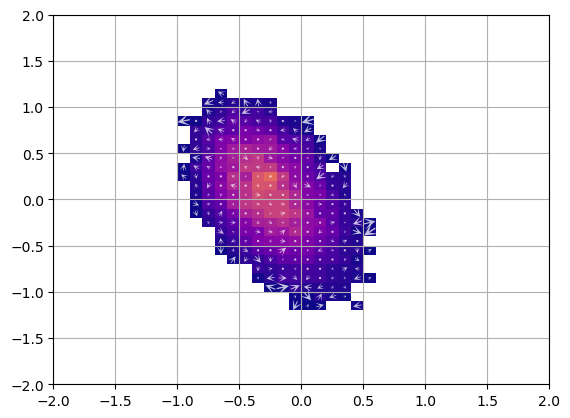

In [165]:
fig, ax = plt.subplots()
arrow_space = 1
samp = (slice(None, None, arrow_space), slice(None, None, arrow_space))  # keeps arrows from being too dense
cmap=plt.cm.plasma.copy()
cmap.set_under('white')
norm=colors.Normalize(vmin=50, vmax=500)
ax.pcolormesh(
    xmesh, 
    ymesh, 
    quiver_data['num_obs'],
    cmap=cmap, 
    norm=norm
)
ax.quiver(
    xmesh[samp],
    ymesh[samp],
    quiver_data['delta_aconv'][samp],
    quiver_data['delta_astrat'][samp],
    angles='xy',
    pivot='middle',
    scale=0.3,
    scale_units='xy',
    width=0.005,
    headwidth=10,
    facecolor='white',
    headlength=10,
    alpha=0.75
)

# ax.quiver(
#     xmesh[samp],
#     ymesh[samp],
#     quiver_data['delta_aconv_bottom'][samp],
#     quiver_data['delta_astrat_bottom'][samp],
#     angles='xy',
#     pivot='middle',
#     scale=0.3,
#     scale_units='xy',
#     width=0.005,
#     headwidth=10,
#     facecolor='green',
#     headlength=10,
#     alpha=0.75
# )


ax.grid()
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)

In [142]:
xmesh==ymesh

array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False,  True]], shape=(399, 399))

In [104]:
quiver_data['num_obs']

np.int64(52)

In [10]:
import numpy as np
import pandas as pd
import xarray as xr

# pcs already standardized across ('lat','lon','time')
std_w = load_coarse_std_gsam_w()                        # (lat, lon)
pcs = load_gsam_eofs_pcs().scores()
pcs = pcs / pcs.std(('lat','lon','time'))
aconv = pcs.sel(mode=1)                                 # (time, lat, lon)
astrat = pcs.sel(mode=2)

pc_bins = np.arange(-10, 10, 0.5)
bin_centers = (pc_bins[:-1] + pc_bins[1:]) / 2

# Forward change to the next time step (Δ at time t := x[t+1] - x[t])
d_aconv = (aconv.shift(time=-1) - aconv).isel(time=slice(None, -1))
d_astrat = (astrat.shift(time=-1) - astrat).isel(time=slice(None, -1))
aconv_t = aconv.isel(time=slice(None, -1))
astrat_t = astrat.isel(time=slice(None, -1))

# Broadcast std_w to match time
std_w_bt = std_w.broadcast_like(aconv_t)                # (time, lat, lon)

# Decile edges for std_w (10 bins)
dec_edges = std_w.quantile(xr.DataArray(np.linspace(0, 1, 11), dims='q')).values
# Assign each grid/time to a decile (1..10)
dec_idx = xr.apply_ufunc(
    np.digitize, std_w_bt, dec_edges[1:-1], kwargs={'right': True}, vectorize=True
) + 1  # 0..9 -> 1..10

# 2-D bin indices for (aconv, astrat), 0-based on bin intervals
xi = xr.apply_ufunc(np.digitize, aconv_t, pc_bins, vectorize=True) - 1
yi = xr.apply_ufunc(np.digitize, astrat_t, pc_bins, vectorize=True) - 1

# Stack to long form
stack_dims = ('time', 'lat', 'lon')
df = pd.DataFrame({
    'decile':   dec_idx.stack(pts=stack_dims).values,
    'xi':       xi.stack(pts=stack_dims).values,
    'yi':       yi.stack(pts=stack_dims).values,
    'd_aconv':  d_aconv.stack(pts=stack_dims).values,
    'd_astrat': d_astrat.stack(pts=stack_dims).values,
})

# Keep only in-range bins and finite deltas
nb = len(pc_bins) - 1
valid = (
    (df['xi'] >= 0) & (df['xi'] < nb) &
    (df['yi'] >= 0) & (df['yi'] < nb) &
    np.isfinite(df['d_aconv']) & np.isfinite(df['d_astrat']) &
    np.isfinite(df['decile'])
)
df = df[valid]

# Group and average
grp = df.groupby(['decile', 'xi', 'yi'])
gA = grp['d_aconv'].mean()
gS = grp['d_astrat'].mean()

# To xarray with bin centers as coords
gA.index.set_names(['decile', 'xbin', 'ybin'], inplace=True)
gS.index.set_names(['decile', 'xbin', 'ybin'], inplace=True)
DA = gA.to_xarray().rename({'xbin':'xbin_idx','ybin':'ybin_idx'})
DS = gS.to_xarray().rename({'xbin':'xbin_idx','ybin':'ybin_idx'})

# Attach bin-center coordinates (map idx -> center)
DA = DA.assign_coords(
    xbin=('xbin_idx', bin_centers[DA['xbin_idx'].values]),
    ybin=('ybin_idx', bin_centers[DA['ybin_idx'].values]),
).swap_dims({'xbin_idx':'xbin', 'ybin_idx':'ybin'}).drop_vars(['xbin_idx','ybin_idx'])

DS = DS.assign_coords(
    xbin=('xbin_idx', bin_centers[DS['xbin_idx'].values]),
    ybin=('ybin_idx', bin_centers[DS['ybin_idx'].values]),
).swap_dims({'xbin_idx':'xbin', 'ybin_idx':'ybin'}).drop_vars(['xbin_idx','ybin_idx'])

# Final dataset: mean Δaconv, Δastrat by (decile, xbin, ybin)
binned = xr.Dataset(
    data_vars=dict(
        mean_d_aconv=DA,
        mean_d_astrat=DS,
    )
).sortby(['decile','xbin','ybin'])

# --- Usage examples ---

# Bottom and top 10% (by std_w):
bottom10 = binned.sel(decile=1)
top10    = binned.sel(decile=10)

# If you want full meshes for plotting:
xmesh, ymesh = np.meshgrid(binned['xbin'].values, binned['ybin'].values, indexing='xy')


ValueError: object of too small depth for desired array

## Binning by $R_{cs}$ and $\theta_{cs}$

In [ ]:
# Load PCs and normalize them by std dev
#
pcs = load_gsam_eofs_pcs().scores()
pcs = pcs/pcs.std(('lat', 'lon', 'time'))
# Compute phase angle, phase number, and radius
# Where radius < 0.5, we set phase number to 0
#
theta = np.arctan2(pcs.sel(mode=2), pcs.sel(mode=1))
radius = np.sqrt(pcs.sel(mode=2)**2 + pcs.sel(mode=1)**2)
# Load std of vertical vel
#
std_mf = load_coarse_std_gsam_w() * load_gsam_reference_profiles().rho
std_mf = std_mf.mean('z')
# Only look at values of theta that fall between -pi/4 and pi/4
#
convective_regime_mask = (radius >= 0.5) & (-np.pi/2 <= theta) & (theta <= np.pi/2)
theta = theta.where(convective_regime_mask, np.nan, drop=False)
radius = radius.where(convective_regime_mask, np.nan, drop=False)
# Compute change in theta (centered difference)
#
initial_theta = theta.isel(time=slice(0, -2)).data
final_theta = theta.isel(time=slice(2, None)).data
delta_theta_data= (final_theta - initial_theta)/3
delta_theta = theta.isel(time=slice(1, -1)).copy(data=delta_theta_data)
# Compute change in radius (centered difference)
#
initial_radius = radius.isel(time=slice(0, -2)).data
final_radius = radius.isel(time=slice(2, None)).data
delta_radius_data= (final_radius - initial_radius)/3
delta_radius = radius.isel(time=slice(1, -1)).copy(data=delta_radius_data)

# Trim radius data
#
radius = radius.sel(time=delta_theta.time)
theta = theta.sel(time=delta_theta.time)
std_mf = std_mf.sel(time=delta_theta.time)

/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_14795/3188255681.py:14: RuntimeWarning: Mean of empty slice
  statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,


Text(0.5, 1.0, 'Mean $\\Delta \\theta_{cs}$ [rad]')

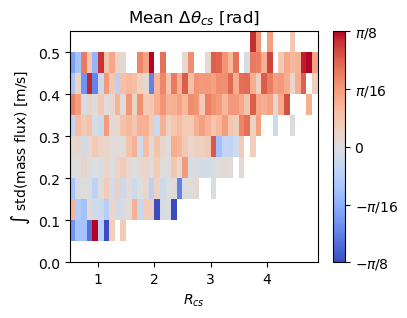

In [5]:
# Compute the mean delta binned by R and theta
#
OBS_THRESH = 5
radius_bins = np.arange(0.5, 5, 0.1)
std_bins = np.arange(0, 1, 0.05)
assert(radius.shape==theta.shape)
# Bin data by theta and radius
#
var_to_bin = delta_theta
bin_mean = binned_statistic_2d(
    std_mf.data.ravel(), 
    radius.data.ravel(),
    var_to_bin.data.ravel(),
    statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,
    bins=[std_bins, radius_bins]
).statistic

# Plot the data
#
fig, ax = plt.subplots(figsize=(4, 3))
xx, yy = np.meshgrid(array_midpoints(radius_bins), array_midpoints(std_bins))
c = ax.pcolormesh(
    xx, yy,
    bin_mean,
    norm=colors.TwoSlopeNorm(vmin=-np.pi/8, vmax=np.pi/8, vcenter=0),
    cmap=plt.cm.coolwarm
)
cb = fig.colorbar(c)
ticks = [-np.pi/8, -np.pi/16, 0, np.pi/16, np.pi/8]
cb.set_ticks(ticks)
cb.set_ticklabels([r"$-\pi/8$", r"$-\pi/16$", "0", r"$\pi/16$", r"$\pi/8$"])
ax.set_ylim(0, 0.55)

ax.set_xlabel(r'$R_{cs}$')
ax.set_ylabel(r"$\int$ std(mass flux) [m/s]")
ax.set_title(r'Mean $\Delta \theta_{cs}$ [rad]')


/var/folders/1t/6drgwyc17q12xmq4h7m454vw0000gn/T/ipykernel_14795/2435789015.py:14: RuntimeWarning: Mean of empty slice
  statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,


Text(0.5, 1.0, 'Mean $\\Delta R_{cs}$ [made up units]')

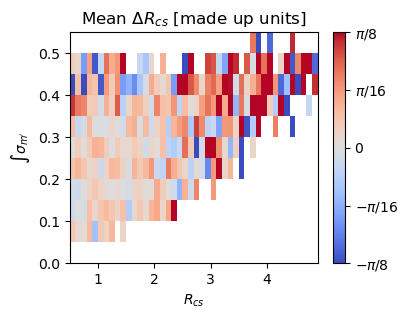

In [7]:
# Compute the mean delta binned by R and theta
#
OBS_THRESH = 5
radius_bins = np.arange(0.5, 5, 0.1)
std_bins = np.arange(0, 1, 0.05)
assert(radius.shape==theta.shape)
# Bin data by theta and radius
#
var_to_bin = delta_radius
bin_mean = binned_statistic_2d(
    std_mf.data.ravel(), 
    radius.data.ravel(),
    var_to_bin.data.ravel(),
    statistic=lambda x: np.nanmean(x) if x.size>OBS_THRESH else np.nan,
    bins=[std_bins, radius_bins]
).statistic

# Plot the data
#
fig, ax = plt.subplots(figsize=(4, 3))
xx, yy = np.meshgrid(array_midpoints(radius_bins), array_midpoints(std_bins))
c = ax.pcolormesh(
    xx, yy,
    bin_mean,
    norm=colors.TwoSlopeNorm(vmin=-np.pi/8, vmax=np.pi/8, vcenter=0),
    cmap=plt.cm.coolwarm
)
cb = fig.colorbar(c)
ticks = [-np.pi/8, -np.pi/16, 0, np.pi/16, np.pi/8]
cb.set_ticks(ticks)
cb.set_ticklabels([r"$-\pi/8$", r"$-\pi/16$", "0", r"$\pi/16$", r"$\pi/8$"])
ax.set_ylim(0, 0.55)

ax.set_xlabel(r'$R_{cs}$')
ax.set_ylabel(r"$\int \sigma_{m'}$")
ax.set_title(r'Mean $\Delta R_{cs}$ [made up units]')


## Binning by $\Delta \theta_{cs}$

In [10]:
# Load PCs and normalize them by std dev
#
pcs = load_gsam_eofs_pcs().scores()
pcs = pcs/pcs.std(('lat', 'lon', 'time'))
# Compute phase angle, phase number, and radius
# Where radius < 0.5, we set phase number to 0
#
theta = np.arctan2(pcs.sel(mode=2), pcs.sel(mode=1))
radius = np.sqrt(pcs.sel(mode=2)**2 + pcs.sel(mode=1)**2)
# Load std of vertical vel
#
std_mf = load_coarse_std_gsam_w() * load_gsam_reference_profiles().rho
std_mf = std_mf.mean('z')
# Only look at values of theta that fall between -pi/4 and pi/4
#
convective_regime_mask = (radius >= 0.5) & (-np.pi/2 <= theta) & (theta <= np.pi/2)
theta = theta.where(convective_regime_mask, np.nan, drop=False)
radius = radius.where(convective_regime_mask, np.nan, drop=False)
# Compute change in theta (centered difference)
#
initial_theta = theta.isel(time=slice(0, -2)).data
final_theta = theta.isel(time=slice(2, None)).data
delta_theta_data= (final_theta - initial_theta)/3
delta_theta = theta.isel(time=slice(1, -1)).copy(data=delta_theta_data)
# Compute change in radius (centered difference)
#
initial_radius = radius.isel(time=slice(0, -2)).data
final_radius = radius.isel(time=slice(2, None)).data
delta_radius_data= (final_radius - initial_radius)/3
delta_radius = radius.isel(time=slice(1, -1)).copy(data=delta_radius_data)

# Trim radius data
#
radius = radius.sel(time=delta_theta.time)
theta = theta.sel(time=delta_theta.time)
std_mf = std_mf.sel(time=delta_theta.time)